# Performance and Regime Comparative Analysis

This analysis compare the regimes identified by HMM method with the regimes identified by Clustering method; the objective is to understand the behavior of the market under different lenses.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pathlib import Path, os

current_dir = Path(os.getcwd())
repo_root = current_dir.parents[2]

PATH_LABELS_PRELIM = repo_root / "data" / "processed" / "labels_prelim.csv"
PATH_DTW_LABELS = repo_root / "data" / "processed" / "dtw_regime_labels.csv"
PATH_DTW_STATS = repo_root / "data" / "reports" / "dtw_regime_stats.csv"
PATH_HMM_STATS = repo_root / "data" / "reports" / "hmm_regime_stats.csv"
PATH_DTW_CLUSTER_STATS = repo_root / "data" / "reports" / "dtw_cluster_stats.csv"
PATH_MARKET_MACRO = repo_root / "data" / "cleaned" / "market_macro_merged.csv"

def load_data():
    """Loads and merges all CSV files into useful DataFrames."""
    labels_prelim = pd.read_csv(PATH_LABELS_PRELIM)
    dtw_labels = pd.read_csv(PATH_DTW_LABELS)
    dtw_stats = pd.read_csv(PATH_DTW_STATS)
    hmm_stats = pd.read_csv(PATH_HMM_STATS)
    dtw_cluster_stats = pd.read_csv(PATH_DTW_CLUSTER_STATS)

    market_data = pd.read_csv(PATH_MARKET_MACRO)
    labels_prelim['date'] = pd.to_datetime(labels_prelim['date'])
    dtw_labels['date'] = pd.to_datetime(dtw_labels['date'])
    market_data['date'] = pd.to_datetime(market_data['date'])
    merged = pd.merge(labels_prelim, dtw_labels, on='date', how='inner')

    merged = pd.merge(merged, market_data[['date', 'close_SPY', 'credit_spread_baa_aaa']], on='date', how='inner')

    merged = merged.rename(columns={'close_SPY': 'spx_close'})

    return labels_prelim, dtw_labels, dtw_stats, hmm_stats, dtw_cluster_stats, merged

labels_prelim, dtw_labels, dtw_stats, hmm_stats, dtw_cluster_stats, merged = load_data()

print("succesfully loaded")

succesfully loaded


# 2. Regime identification

In [44]:
def identify_regimes(stats_df):
    """
    Identifies the Bull and Bear regimes based on financial statistics.

    Args:
        stats_df (pd.DataFrame): DataFrame containing regime statistics
                                 (requires 'Mean_Return' and 'Ann_Volatility' columns).

    Returns:
        tuple: (bull_regime_name, bear_regime_name)
    """
    # Bull: Highest return, lowest volatility (as a tie-breaker)
    bull = stats_df.sort_values(by=['Mean_Return', 'Ann_Volatility'],
                                ascending=[False, True]).iloc[0]['Regime']

    # Bear: Lowest return, highest volatility (as a tie-breaker)
    bear = stats_df.sort_values(by=['Mean_Return', 'Ann_Volatility'],
                                ascending=[True, False]).iloc[0]['Regime']
    return bull, bear

hmm_bull, hmm_bear = identify_regimes(hmm_stats)
dtw_bull, dtw_bear = identify_regimes(dtw_stats)

print("--- REGIME INTERPRETATION ---")
print(f"HMM Model -> Bull: {hmm_bull} | Bear: {hmm_bear}")
print(f"DTW Model -> Bull: {dtw_bull} | Bear: {dtw_bear}\n")

# Display the raw stats for context
print("HMM Statistics:")
display(hmm_stats.round(4))
print("DTW Statistics:")
display(dtw_stats.round(4))

# ==========================================
# 4. OVERLAP ANALYSIS (CONFUSION MATRIX)
# ==========================================
# Merge the HMM labels and DTW labels on the 'date' column
merged_labels = pd.merge(labels_prelim, dtw_labels, on='date', how='inner')

# Create a cross-tabulation (confusion matrix) to see how often regimes overlap
confusion_matrix = pd.crosstab(
    merged_labels['risk_regime'],
    merged_labels['regime_cluster'],
    rownames=['HMM Regime'],
    colnames=['DTW Cluster']
)

print("\n--- REGIME OVERLAP (CONFUSION MATRIX) ---")
print("This table shows how many days each HMM regime overlaps with each DTW cluster.")
display(confusion_matrix)

--- REGIME INTERPRETATION ---
HMM Model -> Bull: Risk-On | Bear: Neutral
DTW Model -> Bull: 2.0 | Bear: 1.0

HMM Statistics:


,Regime,Mean_Return,Ann_Volatility,Max_Drawdown,Days
0,Neutral,-0.0071,0.0585,-0.0169,4
1,Risk-Off,0.0008,0.2131,-0.1455,150
2,Risk-On,0.0085,0.1168,0.0000,9


DTW Statistics:


,Regime,Mean_Return,Ann_Volatility,Max_Drawdown,Days
0,1,0.0004,0.1446,-0.0819,112
1,2,0.0027,0.1461,-0.0267,28
2,3,0.0017,0.4345,-0.0554,23



--- REGIME OVERLAP (CONFUSION MATRIX) ---
This table shows how many days each HMM regime overlaps with each DTW cluster.


DTW Cluster,1,2,3
HMM Regime,,,
Neutral,2,0,2
Risk-Off,108,28,14
Risk-On,2,0,7


# 3. DTW PCA statistics inspection


--- DTW CLUSTER PCA STATISTICS ---
Notice how Cluster 1 (Bear) has heavily negative Market PC1 means.


,cluster,n_windows,market_PC1_mean,credit_PC1_mean,cross_asset_PC1_mean
0,1,112,-1.3403,-0.1769,0.1226
1,2,28,3.2239,1.3552,2.1193
2,3,23,4.0364,0.3231,-2.1322


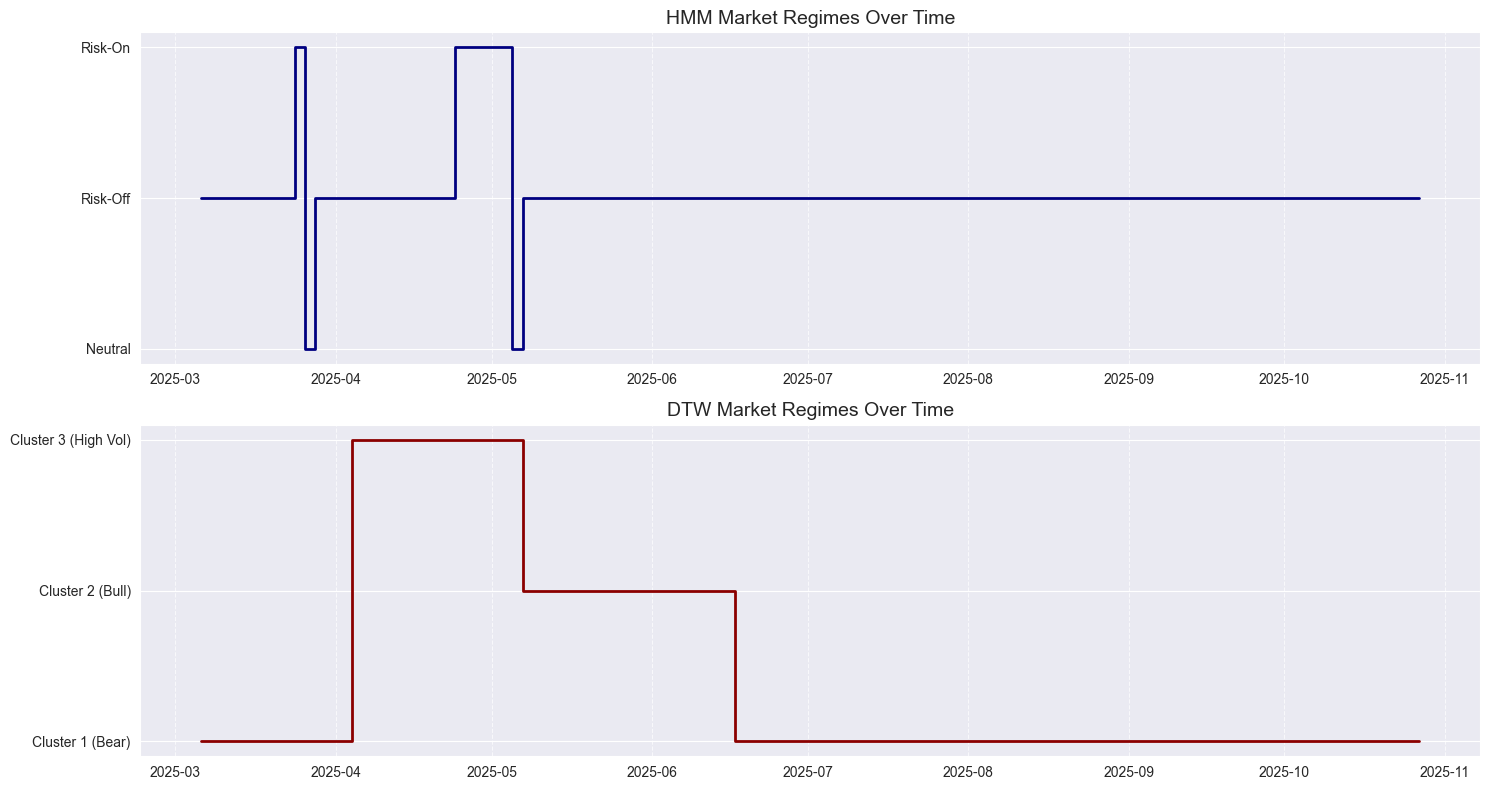

In [45]:
print("\n--- DTW CLUSTER PCA STATISTICS ---")
print("Notice how Cluster 1 (Bear) has heavily negative Market PC1 means.")
# Displaying only the first few relevant columns for readability
display(dtw_cluster_stats[['cluster', 'n_windows', 'market_PC1_mean', 'credit_PC1_mean', 'cross_asset_PC1_mean']].round(4))

# ==========================================
# 6. VISUALIZATION (REGIMES OVER TIME)
# ==========================================
# Sort values by date to ensure the timeline flows correctly left to right
merged_labels = merged_labels.sort_values('date').set_index('date')

# Map HMM string labels ('Neutral', 'Risk-Off', 'Risk-On') to numeric values for plotting
# Note: These mappings are arbitrary and just for vertical separation on the chart.
hmm_mapping = {'Neutral': 0, 'Risk-Off': 1, 'Risk-On': 2}
merged_labels['hmm_numeric'] = merged_labels['risk_regime'].map(hmm_mapping)

# Initialize the plot figure
plt.figure(figsize=(15, 8))

# --- Top Subplot: HMM Regimes ---
plt.subplot(2, 1, 1)
# drawstyle='steps-post' creates the square-wave look typical of regime charts
plt.plot(merged_labels.index, merged_labels['hmm_numeric'],
         drawstyle='steps-post', color='navy', linewidth=2)
plt.yticks(list(hmm_mapping.values()), list(hmm_mapping.keys()))
plt.title('HMM Market Regimes Over Time', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# --- Bottom Subplot: DTW Regimes ---
plt.subplot(2, 1, 2)
plt.plot(merged_labels.index, merged_labels['regime_cluster'],
         drawstyle='steps-post', color='darkred', linewidth=2)
# DTW clusters are numeric (1, 2, 3), we label them for clarity
plt.yticks([1, 2, 3], ['Cluster 1 (Bear)', 'Cluster 2 (Bull)', 'Cluster 3 (High Vol)'])
plt.title('DTW Market Regimes Over Time', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

s## 3. Visualizzazione Avanzata (Price Overlay)

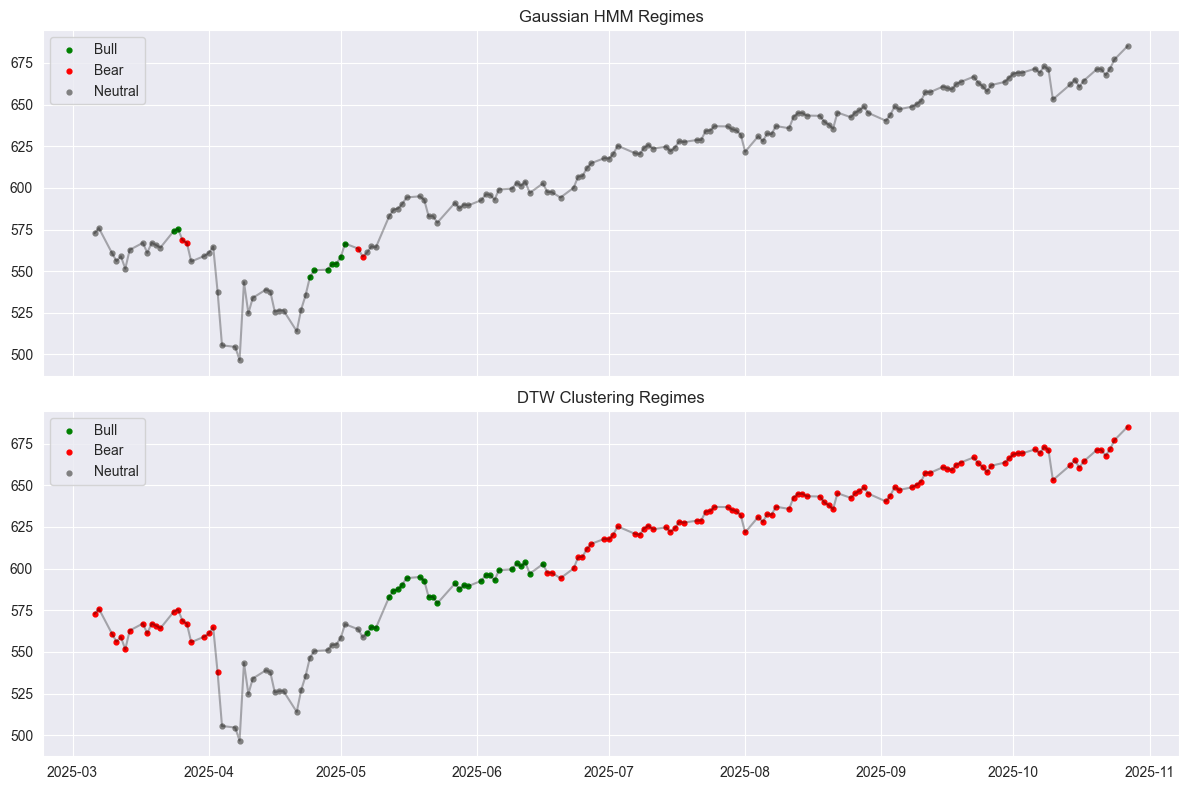

In [46]:
import matplotlib.pyplot as plt

if 'spx_close' not in merged.columns:
    raise ValueError("ERRORE: Colonna 'spx_close' non trovata nel DataFrame. Assicurati di aver caricato i prezzi correttamente.")

merged['HMM_L'] = merged['risk_regime'].map({hmm_bull: 'Bull', hmm_bear: 'Bear'}).fillna('Neutral')
merged['DTW_L'] = merged['regime_cluster'].map({dtw_bull: 'Bull', dtw_bear: 'Bear'}).fillna('Neutral')

colors = {'Bull': 'green', 'Bear': 'red', 'Neutral': 'gray'}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

def quick_plot(ax, label_col, title):
    ax.plot(merged['date'], merged['spx_close'], color='black', alpha=0.3)

    for lbl, clr in colors.items():
        mask = merged[label_col] == lbl
        ax.scatter(merged.loc[mask, 'date'], merged.loc[mask, 'spx_close'], c=clr, label=lbl, s=12)

    ax.set_title(title)
    ax.legend()

quick_plot(axes[0], 'HMM_L', 'Gaussian HMM Regimes')
quick_plot(axes[1], 'DTW_L', 'DTW Clustering Regimes')

plt.tight_layout()
plt.show()

# 4. Agreement analysis

--- COMPARISON RESULTS ---
Overlap Percentage (Congruence): 9.82%
Discrepancy Days: 147 out of 163


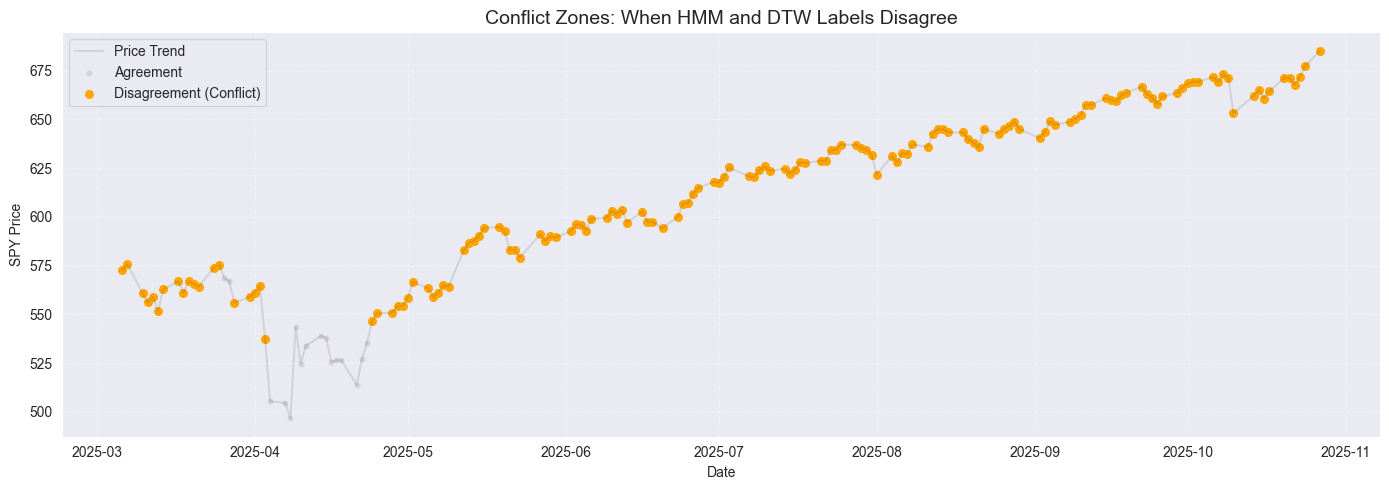


Examples of days with conflicting signals:


,date,HMM_Label,DTW_Label,spx_close
153,2025-10-14,Other/Neutral,Bear,662.20
154,2025-10-15,Other/Neutral,Bear,665.08
155,2025-10-16,Other/Neutral,Bear,660.65
156,2025-10-17,Other/Neutral,Bear,664.32
157,2025-10-20,Other/Neutral,Bear,671.27
158,2025-10-21,Other/Neutral,Bear,671.27
159,2025-10-22,Other/Neutral,Bear,667.79
160,2025-10-23,Other/Neutral,Bear,671.63
161,2025-10-24,Other/Neutral,Bear,677.11
162,2025-10-27,Other/Neutral,Bear,685.18


In [47]:
# ==========================================
# CONGRUENCE ANALYSIS (OVERLAP)
# ==========================================

# 1. Create normalized labels for comparison
# Using the bull/bear variables calculated in previous cells
merged['HMM_Label'] = merged['risk_regime'].apply(
    lambda x: 'Bull' if x == hmm_bull else ('Bear' if x == hmm_bear else 'Other/Neutral')
)
merged['DTW_Label'] = merged['regime_cluster'].apply(
    lambda x: 'Bull' if x == dtw_bull else ('Bear' if x == dtw_bear else 'Other/Neutral')
)

# 2. Calculate Congruence (Overlap percentage)
congruence = (merged['HMM_Label'] == merged['DTW_Label']).mean() * 100
discrepancy_df = merged[merged['HMM_Label'] != merged['DTW_Label']]

print(f"--- COMPARISON RESULTS ---")
print(f"Overlap Percentage (Congruence): {congruence:.2f}%")
print(f"Discrepancy Days: {len(discrepancy_df)} out of {len(merged)}")

# 3. Visualization of model disagreement
plt.figure(figsize=(14, 5))

# Plot the underlying price (SPY) as a reference
plt.plot(merged['date'], merged['spx_close'], color='black', alpha=0.1, label='Price Trend')

# Points where models agree (Gray)
plt.scatter(merged['date'], merged['spx_close'], color='lightgray', s=10, label='Agreement')

# Points where models disagree (Orange)
plt.scatter(discrepancy_df['date'], discrepancy_df['spx_close'], color='orange', s=30, label='Disagreement (Conflict)')

plt.title('Conflict Zones: When HMM and DTW Labels Disagree', fontsize=14)
plt.xlabel('Date')
plt.ylabel('SPY Price')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the most recent discordant days
print("\nExamples of days with conflicting signals:")
display(discrepancy_df[['date', 'HMM_Label', 'DTW_Label', 'spx_close']].tail(10))

# 5. Accuracy analysis

In [48]:
# ==========================================
# MODEL ACCURACY & PERFORMANCE STATISTICS
# ==========================================

# 1. Calculate Forward Returns (Predicting the next day)
# We shift by -1 because we want to know if the label "today"
# accurately predicts the market movement "tomorrow"
merged['Next_Day_Return'] = merged['spx_close'].pct_change().shift(-1)

def get_performance_stats(df, label_col):
    """
    Calculates summary statistics for a given regime labeling.
    """
    stats = df.groupby(label_col)['Next_Day_Return'].agg([
        'count',
        'mean',
        'std'
    ])

    # Calculate Win Rate (Frequency of positive returns)
    stats['win_rate'] = df.groupby(label_col)['Next_Day_Return'].apply(lambda x: (x > 0).mean()) * 100

    # Annualize the Mean Return (assuming 252 trading days)
    stats['annualized_return'] = stats['mean'] * 252 * 100

    # Calculate "Risk-Adjusted" Score (Mean / Std) - Higher is better for Bull
    stats['sharpe_ratio_adj'] = (stats['mean'] / stats['std']) * (252**0.5)

    return stats.rename(columns={
        'count': 'Days',
        'mean': 'Avg Daily Return',
        'std': 'Daily Volatility',
        'win_rate': 'Win Rate (%)',
        'annualized_return': 'Ann. Return (%)'
    })

# 2. Generate Statistics for both models
hmm_summary = get_performance_stats(merged, 'HMM_Label')
dtw_summary = get_performance_stats(merged, 'DTW_Label')

# 3. Display Results
print("--- GAUSSIAN HMM ACCURACY STATISTICS ---")
print("Evaluating how well HMM labels predict the next day's price movement.")
display(hmm_summary.round(4))

print("\n--- DTW CLUSTERING ACCURACY STATISTICS ---")
print("Evaluating how well DTW clusters predict the next day's price movement.")
display(dtw_summary.round(4))

# 4. Summary Findings
print("\n--- KEY INSIGHTS ---")
for model_name, stats in [("HMM", hmm_summary), ("DTW", dtw_summary)]:
    bull_win = stats.loc['Bull', 'Win Rate (%)'] if 'Bull' in stats.index else 0
    bear_win = stats.loc['Bear', 'Win Rate (%)'] if 'Bear' in stats.index else 0

    print(f"[{model_name} Model]")
    print(f" - Bull Predictive Power: {bull_win:.2f}% Win Rate")
    print(f" - Bear Predictive Power: {bear_win:.2f}% Win Rate (Lower is better for identifying crashes)")

--- GAUSSIAN HMM ACCURACY STATISTICS ---
Evaluating how well HMM labels predict the next day's price movement.


,Days,Avg Daily Return,Daily Volatility,Win Rate (%),Ann. Return (%),sharpe_ratio_adj
HMM_Label,,,,,,
Bear,4,-0.0067,0.0101,25.0000,-168.8683,-10.5123
Bull,9,0.0024,0.0077,77.7778,60.5729,4.9701
Other/Neutral,149,0.0013,0.0135,57.3333,33.5474,1.5621



--- DTW CLUSTERING ACCURACY STATISTICS ---
Evaluating how well DTW clusters predict the next day's price movement.


,Days,Avg Daily Return,Daily Volatility,Win Rate (%),Ann. Return (%),sharpe_ratio_adj
DTW_Label,,,,,,
Bear,111,0.0002,0.0106,56.2500,4.1123,0.2452
Bull,28,0.0023,0.0095,60.7143,57.5879,3.8170
Other/Neutral,23,0.0048,0.0243,60.8696,121.7097,3.1588



--- KEY INSIGHTS ---
[HMM Model]
 - Bull Predictive Power: 77.78% Win Rate
 - Bear Predictive Power: 25.00% Win Rate (Lower is better for identifying crashes)
[DTW Model]
 - Bull Predictive Power: 60.71% Win Rate
 - Bear Predictive Power: 56.25% Win Rate (Lower is better for identifying crashes)
